# Predicting Maternal Health Risk Using Machine Learning

This project aims to build a machine learning model capable of predicting maternal health risk levels during pregnancy using demographic and physiological health indicators.

### Problem Definition

Based on measurable health indicators, can we predict whether a pregnancy falls into **"low risk"**, **"mid risk"**, or **"high risk"**?

### Data

The data used is the Maternal Health Risk Dataset from the UCI Machine Learning Repository. https://archive.ics.uci.edu/dataset/863/maternal+health+risk

### Features

1. **Age**: Age in years
2. **SystolicBP:** Upper value of blodd pressure which represents the pressure in the arteries when the heart beats 
3. **DiastolicBP:** Lower value of blood pressure which represents the pressure in the arteries when the heart rests between beats
4. **BS:** Blood Sugar which refers to the concentration of glucose (sugar) circulating in the bloodstream at any given time
5. **BodyTemp:** Body temperature measured in Fahrenheit (°F)
6. **HeartRate:** A normal resting heart rate in beats per minute

### Target variable

**RiskLevel:** Predicts risk intensity level during pregnancy based on the above features

# Importing Libraries

We begin by importing the Python libraries and packages required for data manipulation, visualization, and machine learning:

- **os & pathlib:** Path manipulation
- **pandas:** Data manipulation and analysis
- **numpy:** Numerical computations
- **matplotlib & seaborn:** Data visualization
- **scikit-learn:** Machine learning models and evaluation tools
- **XGBoost:** Gradient boosting algorithm that can be used for classification tasks
- **mord:** For ranking and ordering ordinal data

In [3]:
import os
from pathlib import Path

import pandas as pd  
import numpy as np  
import matplotlib.pyplot as plt  
import seaborn as sns  
  
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV 
from sklearn.preprocessing import StandardScaler

from mord import LogisticIT  
from sklearn.ensemble import RandomForestClassifier  
from xgboost import XGBClassifier, plot_importance
  
from sklearn.metrics import (  
    accuracy_score,  
    confusion_matrix, 
    ConfusionMatrixDisplay,
    classification_report,  
    precision_score,  
    recall_score,  
    f1_score
)  

# Environment Setup

### Load the Dataset

In [6]:
# Set up the project root directory
PROJECT_ROOT = Path(os.getcwd()).parent  
DATA_DIR = PROJECT_ROOT / "data"

# Check if the data folder exists
if not DATA_DIR.exists():
    print(f"Warning: 'data' folder not found in {PROJECT_ROOT}. Please check the project structure.")

# Find the Dataset file using relative path
matches = list(DATA_DIR.rglob("maternal_health_risk.csv"))

if not matches:
    print("Dataset not found in the data folder. Please ensure the dataset is available.")
else:
    file_path = matches[0]
    df = pd.read_csv(file_path)

### Generate `requirements.txt`

In [11]:
#This lists all installed libraries and their versions, ensuring others can recreate the same environment by running:

!pip freeze > requirements.txt

# Exploratory Data Analysis (EDA)

### Initial Data Inspection

Before performing deeper analysis, we examine the structure of the dataset.

In [14]:
# View Dataset dimensions
df.shape

(1014, 7)

In [16]:
# Display first rows
df.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


In [18]:
# Display last rows
df.tail()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
1009,22,120,60,15.0,98.0,80,high risk
1010,55,120,90,18.0,98.0,60,high risk
1011,35,85,60,19.0,98.0,86,high risk
1012,43,120,90,18.0,98.0,70,high risk
1013,32,120,65,6.0,101.0,76,mid risk


In [20]:
# Display summary of the DataFrame structure
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB


In [22]:
# Check missing values
df.isna().sum()

Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64

In [24]:
# View statistical summary
df.describe()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000


In [26]:
# Display unique values for each column
for col in df.columns:
    print(f"{col} unique values: {df[col].unique()}")

Age unique values: [25 35 29 30 23 32 42 19 20 48 15 50 10 40 21 18 16 22 49 28 12 60 55 45
 31 17 26 54 44 33 13 34 38 39 63 14 37 51 62 43 65 66 56 70 27 36 59 24
 41 46]
SystolicBP unique values: [130 140  90 120  85 110  70 100  75  95  76  80 115 135 160 129  83  99
  78]
DiastolicBP unique values: [ 80  90  70  85  60  89  75 100  50  65  95  49  63  69  76  68]
BS unique values: [15.   13.    8.    7.    6.1   7.01 11.    6.9  18.    6.7   7.5   7.2
  7.1   6.4   9.    6.    7.7  12.   16.    7.8   6.8   7.9  17.   19.
 10.    6.3   6.6   6.5   7.6 ]
BodyTemp unique values: [ 98.  100.  102.  101.  103.   98.4  99.   98.6]
HeartRate unique values: [86 70 80 76 78 77 88 90 66 82 60 75 67 65 68  7]
RiskLevel unique values: ['high risk' 'low risk' 'mid risk']


array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'SystolicBP'}>],
       [<Axes: title={'center': 'DiastolicBP'}>,
        <Axes: title={'center': 'BS'}>],
       [<Axes: title={'center': 'BodyTemp'}>,
        <Axes: title={'center': 'HeartRate'}>]], dtype=object)

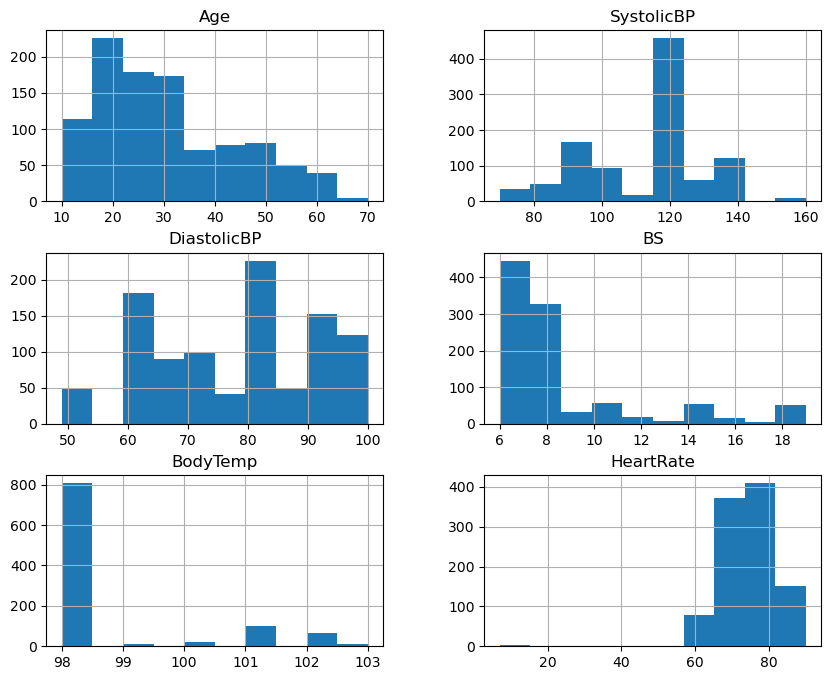

In [28]:
# Visualize distributions of features
df.hist(figsize=(10,8)) 

# Data Preprocessing and Feature Engineering

### Defining and Exploring the Distribution of the Ordered Categorical Variable

In [32]:
# Count occurrences of each class to understand the spread of values
df["RiskLevel"] = pd.Categorical(
    df["RiskLevel"],
    categories=["low risk", "mid risk", "high risk"],
    ordered=True
)

df["RiskLevel"].value_counts().sort_index() 

RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64

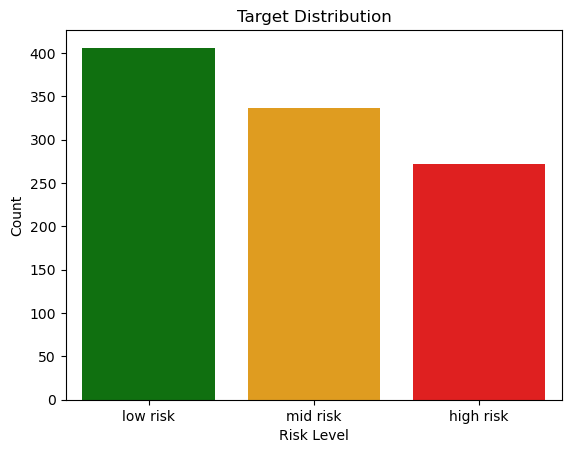

In [34]:
# Visualize class distributions
sns.countplot(
    x="RiskLevel",
    data=df,
    hue="RiskLevel",
    palette=["green", "orange", "red"],
    legend=False
)

plt.title("Target Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.show()

### Target Encoding

Machine learning algorithms require **numerical input** to perform computations.  
Our target variable, **RiskLevel**, is categorical, so we will encode it into numeric values.

In [37]:
# A copy of the original dataset is created before making any changes to preserve the original data and allow safe preprocessing
df_copy = df.copy()

In [39]:
# Ordinal Target Encoding: Mapping categorical values to integers
target_map = {
    "low risk": 0,
    "mid risk": 1,
    "high risk": 2
}

# Create a new numeric target column
df_copy["RiskLevel_encoded"] = df_copy["RiskLevel"].str.lower().map(target_map)

In [41]:
# View the first 10 rows
df_copy.head(10)

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel,RiskLevel_encoded
0,25,130,80,15.00,98.0,86,high risk,2
1,35,140,90,13.00,98.0,70,high risk,2
2,29,90,70,8.00,100.0,80,high risk,2
3,30,140,85,7.00,98.0,70,high risk,2
4,35,120,60,6.10,98.0,76,low risk,0
5,23,140,80,7.01,98.0,70,high risk,2
6,23,130,70,7.01,98.0,78,mid risk,1
7,35,85,60,11.00,102.0,86,high risk,2
8,32,120,90,6.90,98.0,70,mid risk,1
9,42,130,80,18.00,98.0,70,high risk,2


In [43]:
# Check missing values after encoding
df_copy["RiskLevel_encoded"].isna().sum()

0

### Feature Correlation
Correlation analysis helps understand relationships between features. Identifying highly correlated features helps reduce redundancy and improves feature selection and engineering.

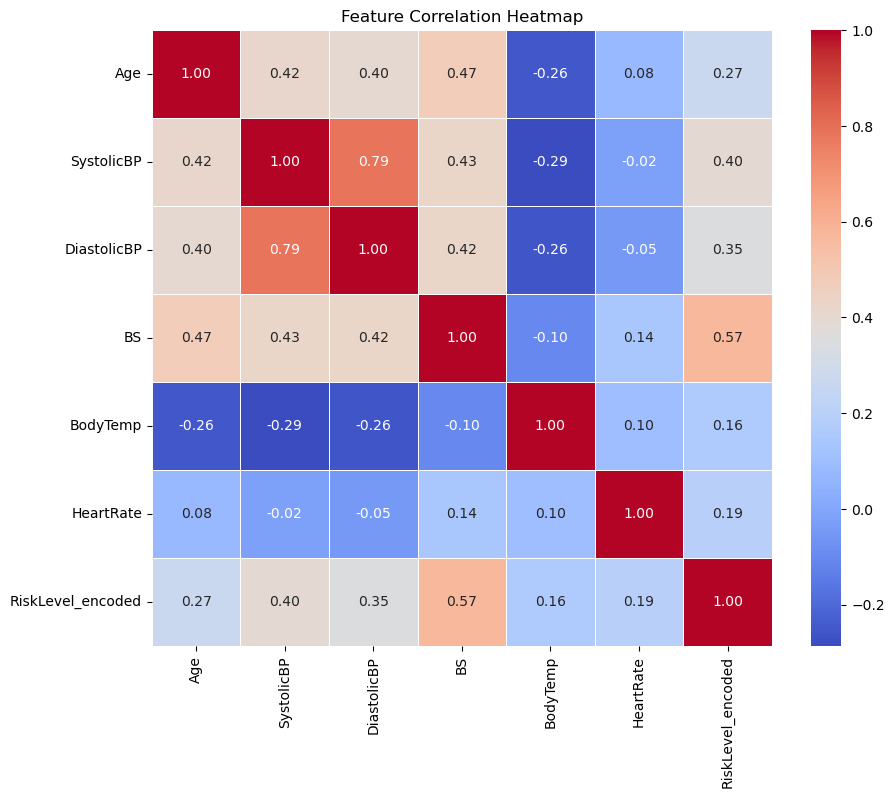

In [46]:
corr_matrix = df_copy.corr(numeric_only=True) 
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix,
            cmap="coolwarm",
            annot=True,
            fmt=".2f",
            linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

# Modeling

### Define Features and Target

- **X (features):** All columns except the target variable (both original and encoded versions)
- **y (target):** Only the encoded numeric target column

In [49]:
# Split Features & Target
X = df_copy.drop(["RiskLevel", "RiskLevel_encoded"], axis=1)
y = df_copy["RiskLevel_encoded"]

### Splitting Data into Training and Testing Sets

In [52]:
# Split the dataset into training and testing sets with an 80-20 ratio and set random seed for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [54]:
# View data types
print(X_train.dtypes)

Age              int64
SystolicBP       int64
DiastolicBP      int64
BS             float64
BodyTemp       float64
HeartRate        int64
dtype: object


### Model Training and Prediction

We will be training three models:

- Ordinal Logistic Regression
- Random Forest Classifier
- XGB Classifier

### Data Scaling

We use **StandardScaler** to standardize features so they contribute equally to the model and avoid dominance by large-value features. Tree-based models like Random Forest and XGBoost do not require scaling, as they are invariant to feature magnitude. Therefore, scaling is used only for Ordinal Logistic Regression, while the other models use the original data.

### Scale Data for Ordinal Logistic Regression

In [59]:
scaler = StandardScaler()

# Fit and transform the scaler on the training set
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same scaling to the test set as used for training
X_test_scaled = scaler.transform(X_test)

### Train and Evaluate Ordinal Logistic Regression

In [62]:
ordinal_logistic_model = LogisticIT()  
ordinal_logistic_model.fit(X_train_scaled, y_train)
y_pred_ordinal = ordinal_logistic_model.predict(X_test_scaled)

### Train and Evaluate Random Forest

In [65]:
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)  
random_forest_model.fit(X_train, y_train)
y_pred_rf = random_forest_model.predict(X_test)

### Train and Evaluate XGBoost

In [68]:
xgboost_model = XGBClassifier(n_estimators=100, random_state=42)  
xgboost_model.fit(X_train, y_train)
y_pred_xgb = xgboost_model.predict(X_test)

### Print All Accuracy Results

In [71]:
# Compare model accuracies
accuracies = {
    "Ordinal Logistic Regression": accuracy_score(y_test, y_pred_ordinal),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "XGBoost": accuracy_score(y_test, y_pred_xgb)
}

# Print accuracies for all models
for model, acc in accuracies.items():
    print(f"{model} Accuracy: {acc}")

Ordinal Logistic Regression Accuracy: 0.6502463054187192
Random Forest Accuracy: 0.8522167487684729
XGBoost Accuracy: 0.8522167487684729


### Hyperparameter Tuning

In [74]:
# Hyperparameter tuning for Ordinal Logistic Regression using GridSearchCV
logisticit_params = {
    "alpha": [0.01, 0.1, 1.0],  
    "max_iter": [100, 200]  
}

logisticit_grid = GridSearchCV(
    LogisticIT(),
    logisticit_params,
    cv=5,
    scoring="accuracy"  
)

# Fit the grid search for Ordinal Logistic Regression
logisticit_grid.fit(X_train_scaled, y_train)
best_logisticit = logisticit_grid.best_estimator_

In [76]:
# Hyperparameter tuning for RandomForestClassifier using GridSearchCV
rf_params = {
    "n_estimators": [100, 200],  
    "max_depth": [None, 5, 10]  
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring="accuracy"  
)

# Fit the grid search for Random Forest
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_

In [78]:
# Hyperparameter tuning for XGBClassifier using GridSearchCV
xgb_params = {
    "n_estimators": [100, 200],  
    "max_depth": [3, 5],  
    "learning_rate": [0.01, 0.1]  
}

xgb_grid = GridSearchCV(
    XGBClassifier(eval_metric='mlogloss'),
    xgb_params,
    cv=5,
    scoring="accuracy"  
)

# Fit the grid search for XGBoost
xgb_grid.fit(X_train, y_train)
best_xgb = xgb_grid.best_estimator_

### Print Best Parameters of All Models

In [81]:
print(f"Best Ordinal LogisticIT Parameters: {logisticit_grid.best_params_}")
print(f"Best Random Forest Parameters: {rf_grid.best_params_}")
print(f"Best XGBoost Parameters: {xgb_grid.best_params_}")

Best Ordinal LogisticIT Parameters: {'alpha': 0.01, 'max_iter': 100}
Best Random Forest Parameters: {'max_depth': None, 'n_estimators': 100}
Best XGBoost Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}


### Model Evaluation: Classification Report and Confusion Matrix Results

We evaluate and print the performances of the three models using the best parameters. 

In [84]:
# Evaluate Ordinal Logistic Regression 
y_pred_ordinal = best_logisticit.predict(X_test_scaled)
print("\nOrdinal Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_ordinal))
print(classification_report(y_test, y_pred_ordinal, zero_division=0))


Ordinal Logistic Regression
Accuracy: 0.6551724137931034
              precision    recall  f1-score   support

           0       0.68      0.80      0.74        81
           1       0.51      0.37      0.43        67
           2       0.73      0.78      0.75        55

    accuracy                           0.66       203
   macro avg       0.64      0.65      0.64       203
weighted avg       0.64      0.66      0.64       203



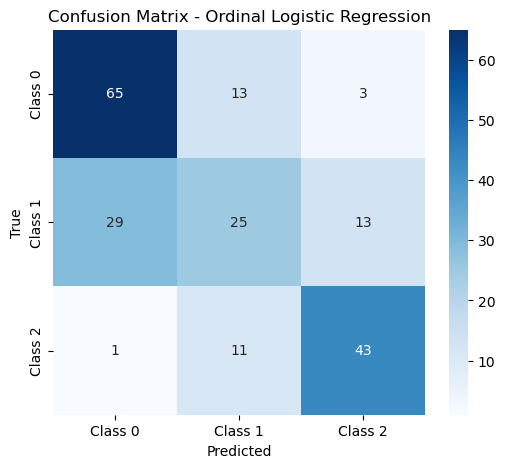

In [86]:
# Confusion Matrix for Ordinal Logistic Regression
cm_ordinal = confusion_matrix(y_test, y_pred_ordinal)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_ordinal, annot=True, fmt="d", cmap="Blues", xticklabels=['Class 0', 'Class 1', 'Class 2'], yticklabels=['Class 0', 'Class 1', 'Class 2'])
plt.title('Confusion Matrix - Ordinal Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [88]:
# Evaluate Random Forest
y_pred_rf = best_rf.predict(X_test)
print("\nRandom Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, zero_division=0))


Random Forest
Accuracy: 0.8522167487684729
              precision    recall  f1-score   support

           0       0.87      0.81      0.84        81
           1       0.79      0.81      0.80        67
           2       0.90      0.96      0.93        55

    accuracy                           0.85       203
   macro avg       0.85      0.86      0.86       203
weighted avg       0.85      0.85      0.85       203



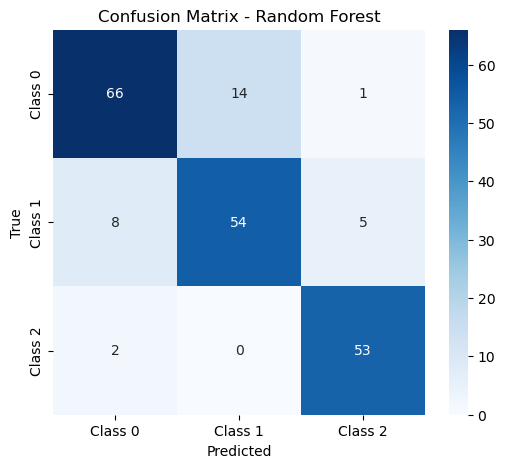

In [90]:
# Confusion Matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues", xticklabels=['Class 0', 'Class 1', 'Class 2'], yticklabels=['Class 0', 'Class 1', 'Class 2'])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [92]:
# Evaluate XGBoost
y_pred_xgb = best_xgb.predict(X_test)
print("\nXGBoost")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb, zero_division=0))


XGBoost
Accuracy: 0.8571428571428571
              precision    recall  f1-score   support

           0       0.86      0.84      0.85        81
           1       0.83      0.79      0.81        67
           2       0.88      0.96      0.92        55

    accuracy                           0.86       203
   macro avg       0.86      0.86      0.86       203
weighted avg       0.86      0.86      0.86       203



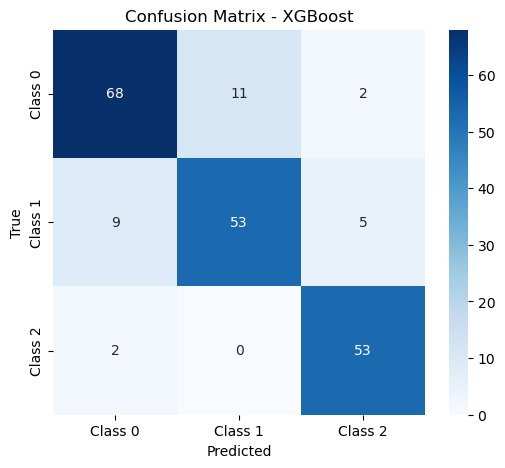

In [94]:
# Confusion Matrix for XGBoost
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Blues", xticklabels=['Class 0', 'Class 1', 'Class 2'], yticklabels=['Class 0', 'Class 1', 'Class 2'])
plt.title('Confusion Matrix - XGBoost')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

### Model Comparison Plot

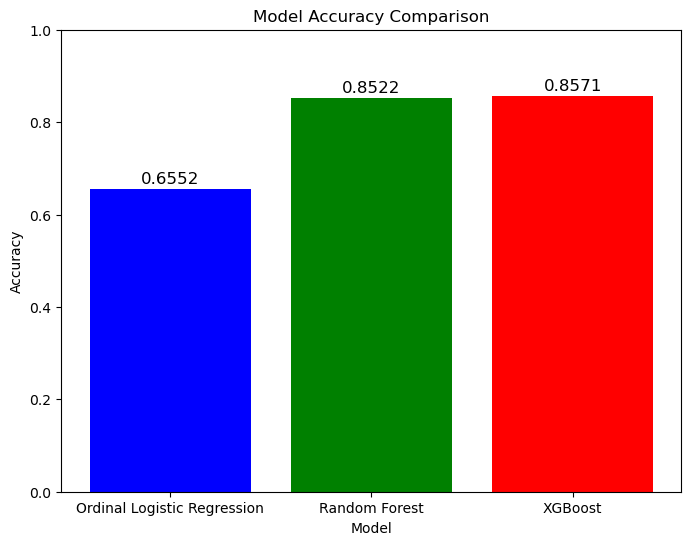

In [97]:
# Model names and corresponding accuracies
models = ['Ordinal Logistic Regression', 'Random Forest', 'XGBoost']
accuracies = [
    accuracy_score(y_test, y_pred_ordinal),  
    accuracy_score(y_test, y_pred_rf),       
    accuracy_score(y_test, y_pred_xgb)       
]

# Plotting the accuracy of each model
plt.figure(figsize=(8, 6))
bars = plt.bar(models, accuracies, color=['blue', 'green', 'red'])

# Adding labels and title
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.ylim([0, 1])  

# Adding the accuracy values above the bars
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.005, f"{v:.4f}", ha='center', va='bottom', fontsize=12)

# Display the plot
plt.show()

### Feature Importance of the Best Model

This helps with:

- **Understanding the model:** Identifies which input variables contribute most to predictions
- **Model refinement:** Guides feature selection by removing less important features and potentially improving performance

<Figure size 1000x600 with 0 Axes>

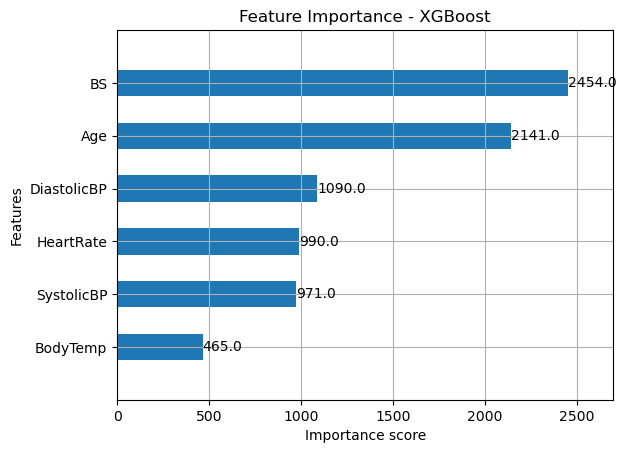

In [100]:
# Plotting feature importance for the model that scored best 
plt.figure(figsize=(10, 6))
plot_importance(best_xgb, 
                importance_type='weight',  
                title='Feature Importance - XGBoost', 
                height=0.5)  

# Display the plot
plt.show()

# Conclusion

After evaluating **Ordinal Logistic Regression**, **Random Forest** and **XGBoost**, we found that:

- **XGBoost** performed best with an accuracy of **0.8571**, slightly ahead of **Random Forest** at **0.8522**.
- **Ordinal Logistic Regression** achieved a lower accuracy of **0.6552**, likely due to its linear nature, which limits its ability to capture complex, non-linear relationships in the data.

Despite its lower performance, **Ordinal Logistic Regression** was included because it naturally models the ordered structure of the target variable and serves as a strong baseline for comparison with more complex models.

Overall, **XGBoost** was the most effective model. The feature importance analysis also highlighted key predictive features, reinforcing the advantage of tree-based models for non-linear data.

### Final Remark:
- **XGBoost** is the best-performing model for this dataset. Further feature engineering could potentially improve performance.
